# 预处理结果概览（图表版）

把 `01_parse_nbib.ipynb` 清洗后的成果，用 Python 画成图来展示。

- **第一层 · 预处理交出了什么**：字段完整度、清洗去重流水、语料规模
- **第二层 · 数据是什么构成**：逐年发文量、来源×年份、作者规模、多值字段

> 输入：`data/interim/articles.csv`、`data/interim/authors.csv`
> 全部图表在 notebook 内联显示，不写文件。


In [1]:
import os
import glob
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ---------- 中文字体（自动挑一个系统里有的）----------
available = {f.name for f in font_manager.fontManager.ttflist}
for cand in ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'Source Han Sans SC', 'PingFang SC']:
    if cand in available:
        plt.rcParams['font.sans-serif'] = [cand]
        break
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.axisbelow'] = True

# ---------- 统一配色 ----------
C_MAIN, C_ACC, C_GREY, C_GREEN = '#2b6cb0', '#dd6b20', '#a0aec0', '#38a169'

print('使用字体:', plt.rcParams['font.sans-serif'][0])


使用字体: Microsoft YaHei


In [2]:
# ---------- 定位项目根目录（data/ 所在的那一级）----------
def find_root(start=None):
    p = os.path.abspath(start or os.getcwd())
    for _ in range(5):
        if os.path.isdir(os.path.join(p, 'data', 'interim')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(start or os.getcwd())

ROOT    = find_root()
INTERIM = os.path.join(ROOT, 'data', 'interim')
RAW     = os.path.join(ROOT, 'data', 'raw')

pd.set_option('display.max_rows', 200)

# ---------- 读数据（表头带 BOM，用 utf-8-sig）----------
articles = pd.read_csv(os.path.join(INTERIM, 'articles.csv'),
                       dtype=str, keep_default_na=False, encoding='utf-8-sig')
authors  = pd.read_csv(os.path.join(INTERIM, 'authors.csv'),
                       dtype=str, keep_default_na=False, encoding='utf-8-sig')

print('项目根目录 :', ROOT)
print(f'articles.csv : {articles.shape[0]:,} 行 × {articles.shape[1]} 列')
print(f'authors.csv  : {authors.shape[0]:,} 行 × {authors.shape[1]} 列')

# ---------- 图片输出目录 + 保存函数 ----------
FIG_DIR = os.path.join(ROOT, 'outputs', 'figures', 'preprocess')
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    path = os.path.join(FIG_DIR, name + '.png')
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print('已保存:', os.path.relpath(path, ROOT))


项目根目录 : D:\MEDscience_map_of_XJTU.wt\viz
articles.csv : 29,907 行 × 22 列
authors.csv  : 275,392 行 × 6 列


In [3]:
# ---------- 常用派生量，后面各图共用 ----------
def split_multi(series, sep='||'):
    out = []
    for v in series:
        if v:
            out.extend(x.strip() for x in v.split(sep) if x.strip())
    return out

n_authors = pd.to_numeric(articles.n_authors)
kw_tokens = split_multi(articles.keywords)
mh_tokens = split_multi(articles.mesh)
kw_unique = len({x.lower() for x in kw_tokens})
mh_unique = len({x.lower() for x in mh_tokens})


---
## 第一层 · 1. 字段完整度

每个字段的非空比例。覆盖率低多是 PubMed 本身的可选字段（ORCID 只有注册作者才有、
MeSH 只有被 MEDLINE 标引后才出现），这里一眼看清哪些字段可用、哪些要谨慎。


已保存: outputs\figures\preprocess\01_field_coverage.png


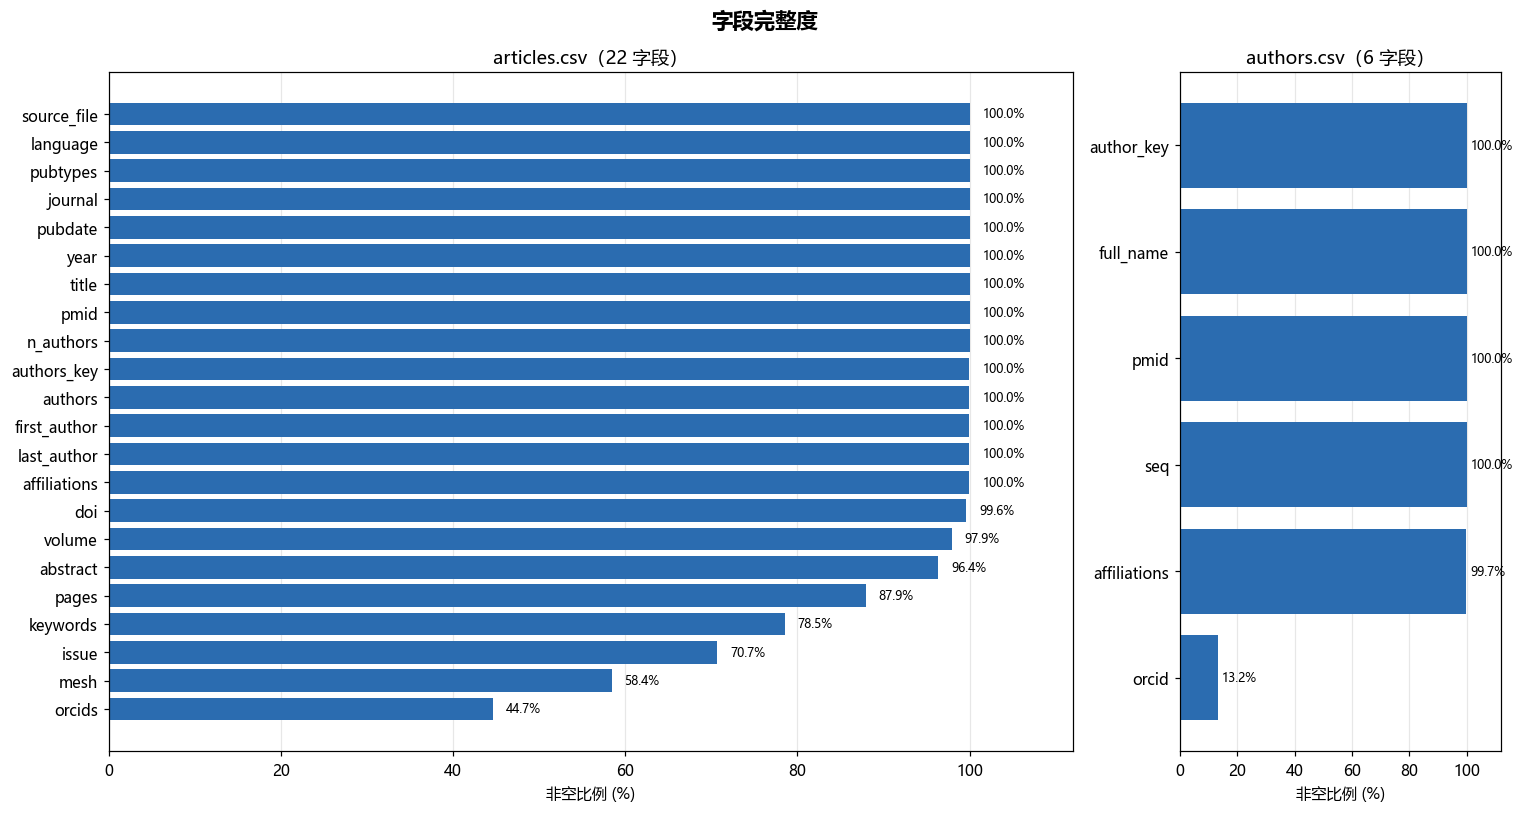

In [4]:
def coverage(df):
    return (df != '').mean().mul(100)

cov_a, cov_b = coverage(articles), coverage(authors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7.5),
                              gridspec_kw={'width_ratios': [3, 1]})

for ax, cov, title in [(ax1, cov_a.sort_values(), 'articles.csv（22 字段）'),
                       (ax2, cov_b.sort_values(), 'authors.csv（6 字段）')]:
    ax.barh(cov.index, cov.values, color=C_MAIN)
    ax.set_xlim(0, 112)
    ax.set_xlabel('非空比例 (%)')
    ax.set_title(title)
    for i, v in enumerate(cov.values):
        ax.text(v + 1.5, i, f'{v:.1f}%', va='center', fontsize=8)
    ax.grid(axis='x', alpha=0.3); ax.grid(axis='y', visible=False)

fig.suptitle('字段完整度', fontsize=14, fontweight='bold')
fig.tight_layout()
save_fig('01_field_coverage')
plt.show()


---
## 第一层 · 2. 清洗去重流水

逐年检索会因电子版/纸质版日期差异产生跨年重复，预处理按 **PMID 去重**。
图中每根柱子 = 一个原始文件导出的记录数，蓝色是去重后保留、橙色是被删掉的跨年重复。


已保存: outputs\figures\preprocess\02_dedup_pipeline.png


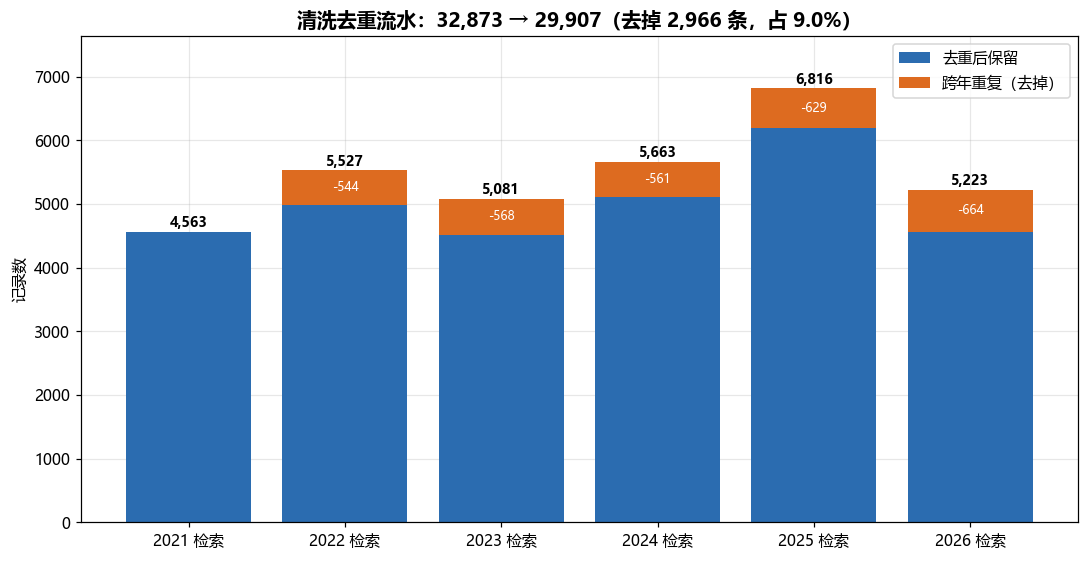

In [5]:
raw_files = sorted(glob.glob(os.path.join(RAW, 'pubmed-XJTU-*.nbib')))
raw_counts = {}
for f in raw_files:
    with open(f, encoding='utf-8') as fh:
        raw_counts[os.path.basename(f)] = sum(1 for line in fh if line.startswith('PMID- '))

kept_counts = articles.source_file.value_counts().to_dict()

files  = sorted(raw_counts)
kept   = np.array([kept_counts.get(f, 0) for f in files])
raw    = np.array([raw_counts[f] for f in files])
dropped = raw - kept
xlabels = [f"{re.search(r'([0-9]{4})', f).group(1)} 检索" for f in files]

fig, ax = plt.subplots(figsize=(10, 5.2))
x = np.arange(len(files))
ax.bar(x, kept, color=C_MAIN, label='去重后保留')
ax.bar(x, dropped, bottom=kept, color=C_ACC, label='跨年重复（去掉）')

for xi, r, d in zip(x, raw, dropped):
    ax.text(xi, r + 70, f'{r:,}', ha='center', fontsize=9, fontweight='bold')
    if d:
        ax.text(xi, r - d / 2, f'-{d:,}', ha='center', va='center',
                color='white', fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(xlabels)
ax.set_ylabel('记录数')
ax.set_ylim(0, raw.max() * 1.12)
ax.set_title(f'清洗去重流水：{raw.sum():,} → {kept.sum():,}'
             f'（去掉 {dropped.sum():,} 条，占 {dropped.sum()/raw.sum()*100:.1f}%）',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('02_dedup_pipeline')
plt.show()


---
## 第一层 · 3. 语料规模

三张小图：实体规模（文章/作者/期刊）、词表规模（关键词与 MeSH 拆开后的总数与去重数）、
平均每篇的数量。


已保存: outputs\figures\preprocess\03_corpus_scale.png


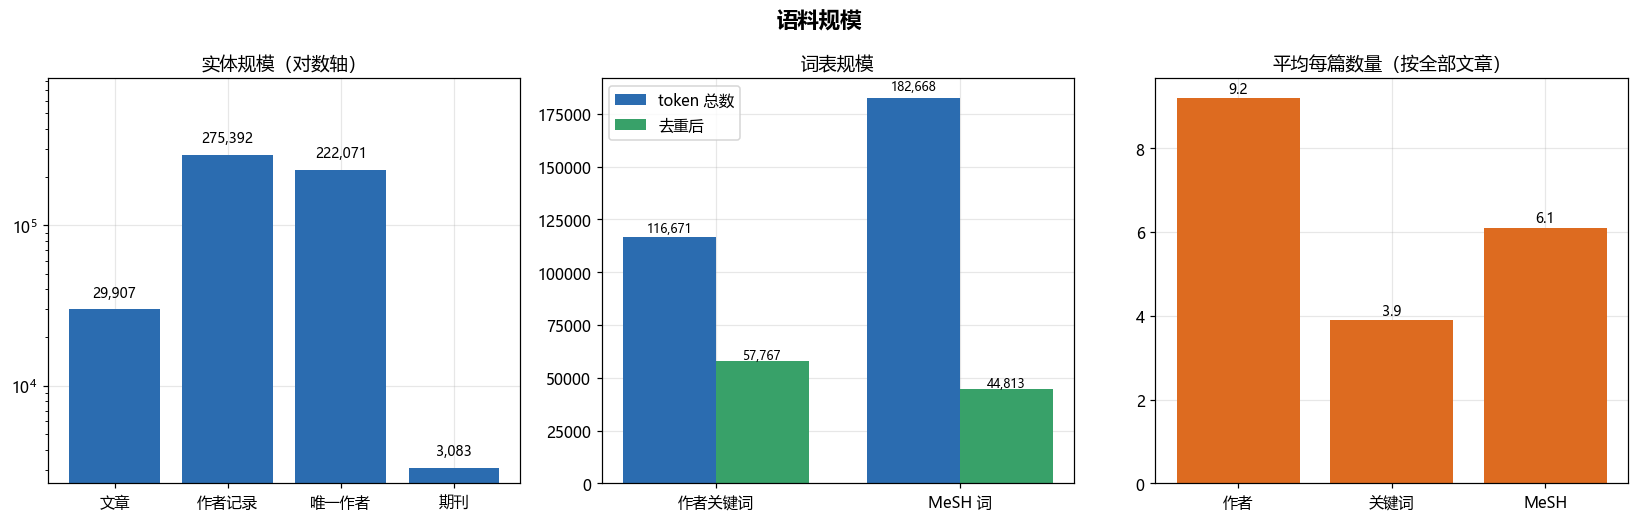

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))

# (1) 实体规模
ents = {'文章': len(articles), '作者记录': len(authors),
        '唯一作者': authors.author_key.nunique(), '期刊': articles.journal.nunique()}
ax = axes[0]
bars = ax.bar(list(ents), list(ents.values()), color=C_MAIN)
ax.set_yscale('log')
ax.set_ylim(top=max(ents.values()) * 3)   # 给顶部标注留空间
ax.set_title('实体规模（对数轴）')
for b, v in zip(bars, ents.values()):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.2, f'{v:,}', ha='center', fontsize=9)

# (2) 词表规模
ax = axes[1]
tot = [len(kw_tokens), len(mh_tokens)]
uni = [kw_unique, mh_unique]
xi, w = np.arange(2), 0.38
ax.bar(xi - w / 2, tot, w, color=C_MAIN, label='token 总数')
ax.bar(xi + w / 2, uni, w, color=C_GREEN, label='去重后')
ax.set_xticks(xi); ax.set_xticklabels(['作者关键词', 'MeSH 词'])
ax.set_title('词表规模')
ax.legend()
for x0, v in zip(xi - w / 2, tot): ax.text(x0, v * 1.02, f'{v:,}', ha='center', fontsize=8)
for x0, v in zip(xi + w / 2, uni): ax.text(x0, v * 1.02, f'{v:,}', ha='center', fontsize=8)

# (3) 平均每篇
ax = axes[2]
avg = {'作者': n_authors.mean(), '关键词': len(kw_tokens) / len(articles),
       'MeSH': len(mh_tokens) / len(articles)}
bars = ax.bar(list(avg), list(avg.values()), color=C_ACC)
ax.set_title('平均每篇数量（按全部文章）')
for b, v in zip(bars, avg.values()):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.12, f'{v:.1f}', ha='center', fontsize=9)

fig.suptitle('语料规模', fontsize=14, fontweight='bold')
fig.tight_layout()
save_fig('03_corpus_scale')
plt.show()


---
## 第二层 · 4. 逐年发文量

柱子是每年文章数；**灰色** = 早于检索年份（电子优先发表溢出），**橙色** = 2026
（检索时该年还没结束，数量不完整），绿色折线是累计占比。


已保存: outputs\figures\preprocess\04_yearly_output.png


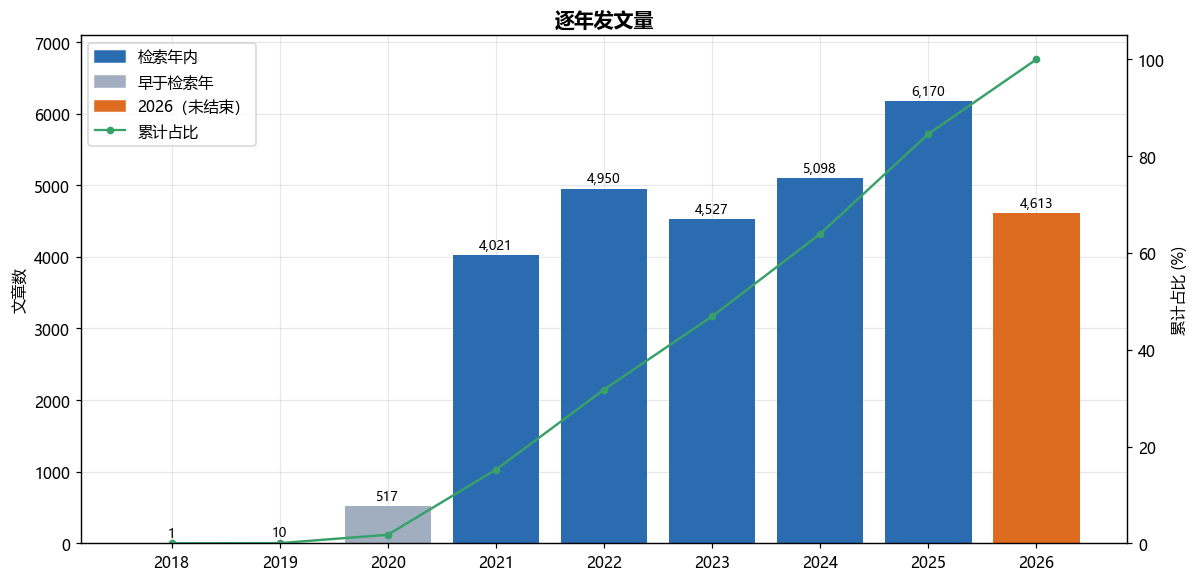

In [7]:
yc = articles.year.value_counts().sort_index()
years, counts = yc.index.tolist(), yc.values.astype(int)
cum = np.cumsum(counts) / counts.sum() * 100
colors = [C_GREY if int(y) < 2021 else (C_ACC if int(y) >= 2026 else C_MAIN) for y in years]

fig, ax = plt.subplots(figsize=(11, 5.4))
bars = ax.bar(years, counts, color=colors)
for b, v in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, v + 90, f'{v:,}', ha='center', fontsize=8.5)

ax.set_ylabel('文章数'); ax.set_ylim(0, counts.max() * 1.15)
ax.set_title('逐年发文量', fontsize=13, fontweight='bold')

ax2 = ax.twinx()
ax2.plot(years, cum, color=C_GREEN, marker='o', ms=4, lw=1.6, label='累计占比')
ax2.set_ylabel('累计占比 (%)'); ax2.set_ylim(0, 105); ax2.grid(False)

handles = [plt.Rectangle((0, 0), 1, 1, color=C_MAIN),
           plt.Rectangle((0, 0), 1, 1, color=C_GREY),
           plt.Rectangle((0, 0), 1, 1, color=C_ACC),
           plt.Line2D([0], [0], color=C_GREEN, marker='o', ms=4)]
ax.legend(handles, ['检索年内', '早于检索年', '2026（未结束）', '累计占比'],
          loc='upper left')
plt.tight_layout()
save_fig('04_yearly_output')
plt.show()


---
## 第二层 · 5. 来源检索文件 × 出版年份（热力图）

行 = 检索时导出的文件夹（按年），列 = 出版年份，格子数字为文章数。
**对角线外**的数字就是年份溢出的来源，能看出哪些记录是从哪次检索"漏"进来的。


已保存: outputs\figures\preprocess\05_source_year_heatmap.png


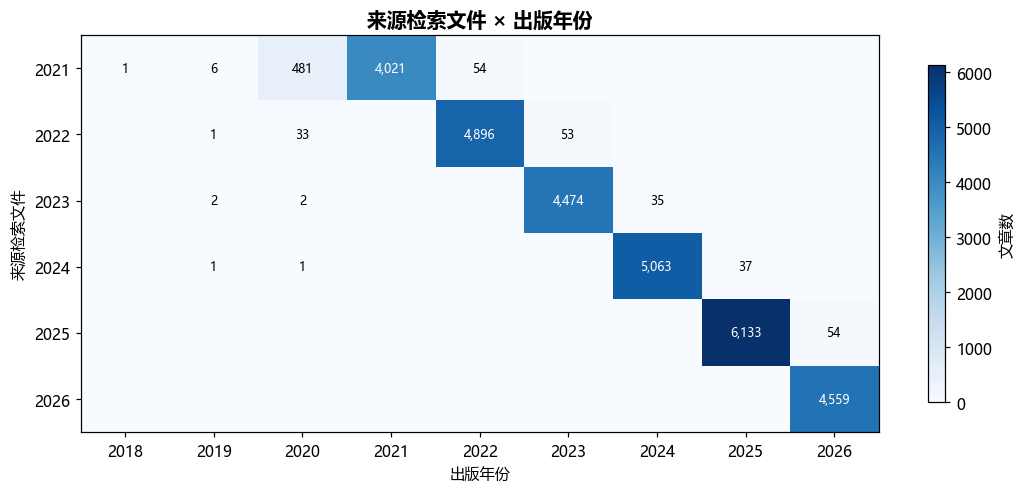

In [8]:
xt = pd.crosstab(articles.source_file, articles.year)
row_labels = [re.search(r'([0-9]{4})', i).group(1) for i in xt.index]
vmax = xt.values.max()

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.imshow(xt.values, aspect='auto', cmap='Blues', vmin=0, vmax=vmax)
ax.set_xticks(range(len(xt.columns))); ax.set_xticklabels(xt.columns)
ax.set_yticks(range(len(xt.index)));  ax.set_yticklabels(row_labels)
ax.set_xlabel('出版年份'); ax.set_ylabel('来源检索文件')
ax.set_title('来源检索文件 × 出版年份', fontsize=13, fontweight='bold')
ax.grid(False)

for i in range(xt.shape[0]):
    for j in range(xt.shape[1]):
        v = xt.values[i, j]
        if v:
            ax.text(j, i, f'{v:,}', ha='center', va='center', fontsize=8,
                    color='white' if v > vmax * 0.55 else 'black')

fig.colorbar(im, ax=ax, shrink=0.85, label='文章数')
plt.tight_layout()
save_fig('05_source_year_heatmap')
plt.show()


---
## 第二层 · 6. 作者规模

左图：每篇作者数分桶。右图：作者数的分布直方图（对数纵轴），可以看到很长的尾巴——
少数超大合作（最多 761 人）会把均值拉高，所以同时标出中位数。


已保存: outputs\figures\preprocess\06_author_size.png


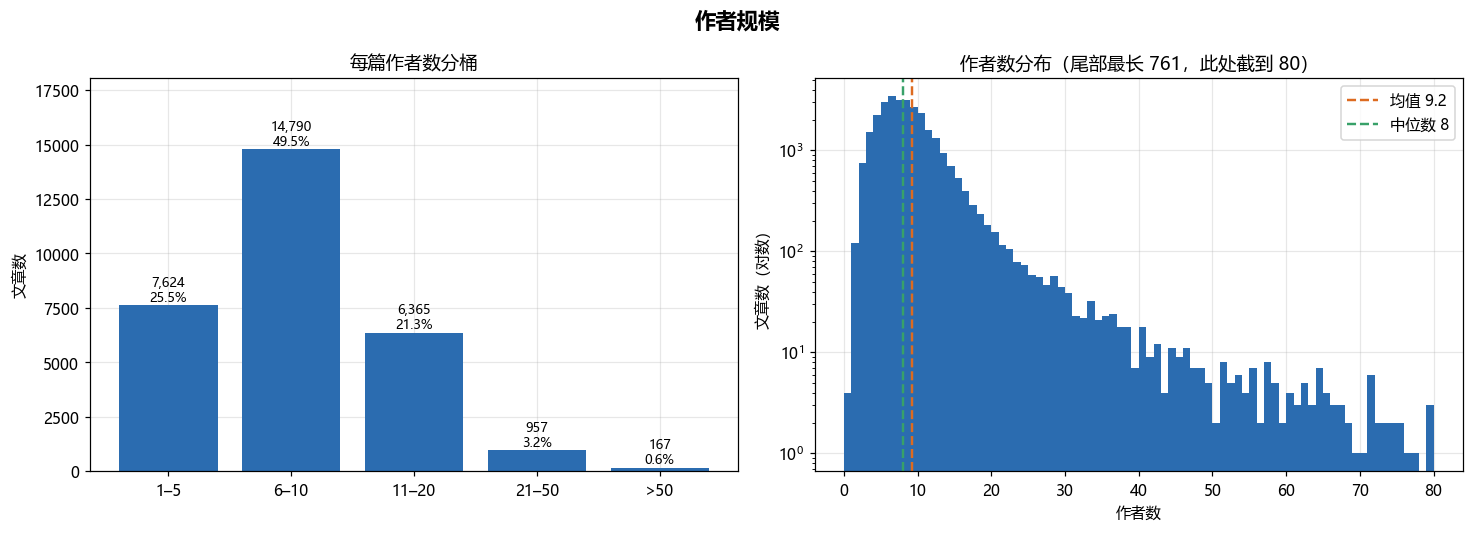

In [9]:
labels = ['1–5', '6–10', '11–20', '21–50', '>50']
buckets = pd.cut(n_authors, bins=[0, 5, 10, 20, 50, np.inf], labels=labels)
vc = buckets.value_counts().reindex(labels).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.9))

ax = axes[0]
bars = ax.bar(labels, vc.values, color=C_MAIN)
for b, v in zip(bars, vc.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 180,
            f'{int(v):,}\n{v/len(articles)*100:.1f}%', ha='center', fontsize=8.5)
ax.set_ylim(0, vc.max() * 1.22)
ax.set_title('每篇作者数分桶'); ax.set_ylabel('文章数')

ax = axes[1]
ax.hist(n_authors, bins=np.arange(0, 81, 1), color=C_MAIN)
ax.set_yscale('log')
ax.axvline(n_authors.mean(), color=C_ACC, ls='--', lw=1.6,
           label=f'均值 {n_authors.mean():.1f}')
ax.axvline(n_authors.median(), color=C_GREEN, ls='--', lw=1.6,
           label=f'中位数 {int(n_authors.median())}')
ax.set_xlabel('作者数'); ax.set_ylabel('文章数（对数）')
ax.set_title(f'作者数分布（尾部最长 {int(n_authors.max())}，此处截到 80）')
ax.legend()

fig.suptitle('作者规模', fontsize=14, fontweight='bold')
fig.tight_layout()
save_fig('06_author_size')
plt.show()


---
## 第二层 · 7. 取值规范待处理

左图：哪些字段用 `||` 塞了多个值（橙色部分做分析前必须先拆分）。
右图：`language` 的取值分布，能看到 `eng||chi` 这类组合值。


已保存: outputs\figures\preprocess\07_multivalue_fields.png


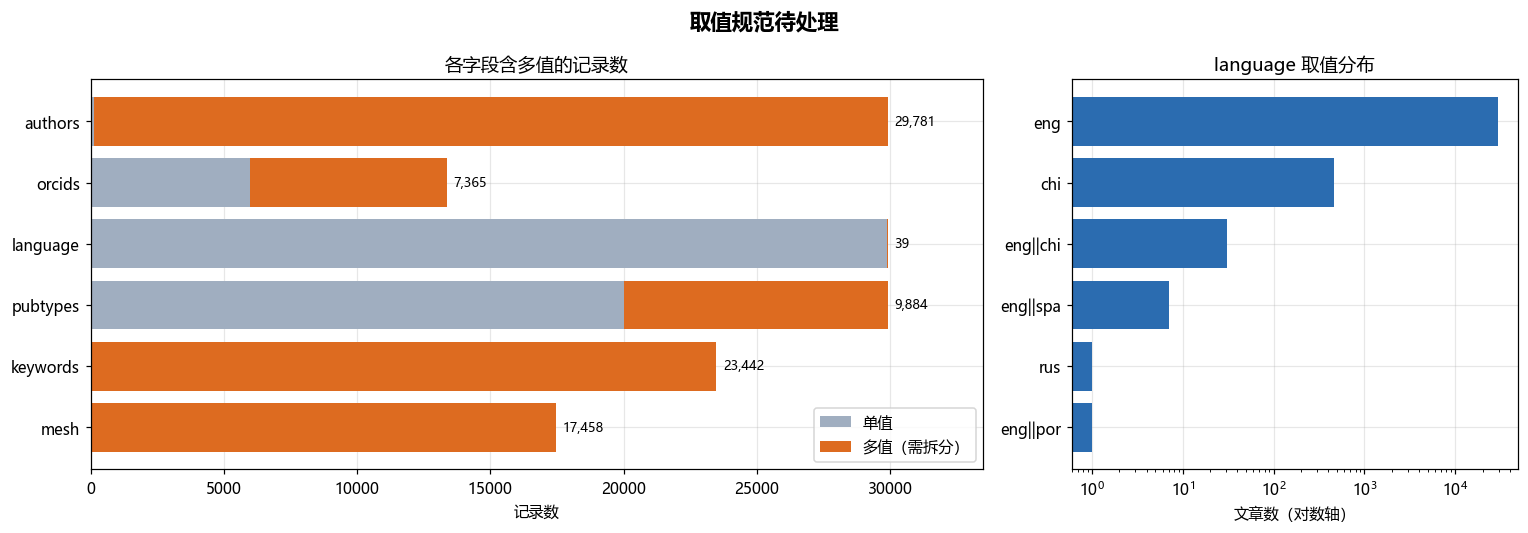

In [10]:
fields = ['authors', 'orcids', 'language', 'pubtypes', 'keywords', 'mesh']
single, multi = [], []
for c in fields:
    m = int(articles[c].str.contains(r'\|\|', regex=True).sum())
    nonempty = int((articles[c] != '').sum())
    multi.append(m); single.append(nonempty - m)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.9),
                         gridspec_kw={'width_ratios': [2, 1]})

ax = axes[0]
y = np.arange(len(fields))
ax.barh(y, single, color=C_GREY, label='单值')
ax.barh(y, multi, left=single, color=C_ACC, label='多值（需拆分）')
ax.set_yticks(y); ax.set_yticklabels(fields); ax.invert_yaxis()
for yi, s, m in zip(y, single, multi):
    ax.text(s + m + 250, yi, f'{m:,}', va='center', fontsize=8.5)
ax.set_xlim(0, max(np.array(single) + np.array(multi)) * 1.12)  # 给右侧标注留空间
ax.set_xlabel('记录数')
ax.set_title('各字段含多值的记录数')
ax.legend()

ax = axes[1]
lc = articles.language.value_counts().head(8)
ax.barh(range(len(lc)), lc.values, color=C_MAIN)
ax.set_yticks(range(len(lc))); ax.set_yticklabels(lc.index); ax.invert_yaxis()
ax.set_xscale('log'); ax.set_xlabel('文章数（对数轴）')
ax.set_title('language 取值分布')

fig.suptitle('取值规范待处理', fontsize=14, fontweight='bold')
fig.tight_layout()
save_fig('07_multivalue_fields')
plt.show()
